In [15]:
import pandas as pd
import dotenv
from datetime import datetime, timedelta, timezone

dotenv.load_dotenv()

True

In [16]:
file_paths = ["data/therapy_submissions.jsonl"]

for path in file_paths:
    with open(path, 'r', encoding='utf-8') as f:
        for i in range(2):
            print(f.readline())

{"archived":true,"author":"zzorg","author_flair_background_color":null,"author_flair_css_class":null,"author_flair_richtext":[],"author_flair_text":null,"author_flair_text_color":null,"author_flair_type":"text","brand_safe":false,"can_gild":true,"contest_mode":false,"created_utc":1275338240,"distinguished":null,"domain":"alandbell.co.uk","edited":false,"gilded":0,"hidden":false,"hide_score":false,"id":"ca07q","is_crosspostable":false,"is_reddit_media_domain":false,"is_self":false,"is_video":false,"link_flair_css_class":null,"link_flair_richtext":[],"link_flair_text":null,"link_flair_text_color":"dark","link_flair_type":"text","locked":false,"media":null,"media_embed":{},"no_follow":true,"num_comments":0,"num_crossposts":0,"over_18":false,"parent_whitelist_status":null,"permalink":"\/r\/therapy\/comments\/ca07q\/alan_d_bell_clinical_hypnotherapist\/","retrieved_on":1522924137,"rte_mode":"markdown","score":2,"secure_media":null,"secure_media_embed":{},"selftext":"","send_replies":true,"s

In [18]:
chunksize = 100_000  # tune for your RAM

# compute cutoff for "last year" from now
cutoff_dt = datetime.now(timezone.utc) - timedelta(days=365*2)
cutoff_ts = cutoff_dt.timestamp()

frames = []

for file in file_paths:
    for chunk in pd.read_json(file, lines=True, chunksize=chunksize):
        chunk = chunk[chunk["created_utc"] >= cutoff_ts]

        # drop deleted/removed posts
        chunk = chunk[~chunk["selftext"].isin(["[deleted]", "[removed]"])]
        chunk = chunk[~chunk["author"].isin(["[deleted]", "[removed]"])]

        if len(chunk):
            frames.append(chunk)

time_filtered_df = pd.concat(frames, ignore_index=True)
clean_df = time_filtered_df[
    [
        "author",
        "selftext",
        "created_utc",
        "title",
        "permalink",
        "id",
        "subreddit",
        "subreddit_id",
        "link_flair_text",
        "retrieved_on",
    ]
].copy()                                                                                                                                                                                                  
                                                                                                                                                                                                        
# drop rows missing required fields only
clean_df = clean_df.dropna(subset=["author", "selftext", "created_utc", "title", "permalink", "id", "subreddit", "subreddit_id", "retrieved_on"])     

# add t3_ prefix to id and rename to post_id
# chromadb uses "id" to identify documents
clean_df["post_id"] = "t3_" + clean_df["id"].astype(str)
clean_df = clean_df.drop(columns=["id"])

print(len(clean_df), "rows in last 1 years after filtering")

35127 rows in last 1 years after filtering


subreddit
therapy    100.0


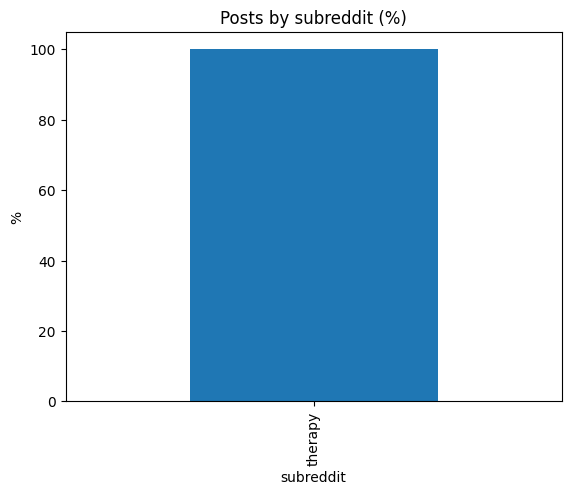

In [19]:
counts = clean_df["subreddit"].value_counts()
pct = (counts / counts.sum() * 100).round(1)
pct.plot(kind="bar", title="Posts by subreddit (%)", ylabel="%");
print(pct.to_string())

## Inspecting Data

Huh. Turns out there's a lot of entries with no text. Let's get rid of them. Only keep entries with 100+ words.

In [20]:
selftext_lengths = clean_df["selftext"].fillna("").apply(lambda x: len(str(x).split()))
title_lengths = clean_df["title"].fillna("").apply(lambda x: len(str(x).split()))

zero_len_df = clean_df[selftext_lengths == 0]

print(f"Number of posts with 0-word selftext: {len(zero_len_df)}")
print(zero_len_df[["author", "title", "selftext", "permalink"]].head(5).to_string(index=False))

Number of posts with 0-word selftext: 3
      author                                                                      title selftext                                                                   permalink
stchrysostom                                                                    ANYWAY…                                                  /r/therapy/comments/1cphc52/anyway/
stchrysostom                                                                    ANYWAY…                                                  /r/therapy/comments/1cphc79/anyway/
stchrysostom My Aunt said therapy is for the Faithless, So I let her quote my therapist          /r/therapy/comments/1l470gb/my_aunt_said_therapy_is_for_the_faithless_so_i/


In [21]:
clean_df = clean_df[selftext_lengths > 100]
print(f"{len(clean_df)} rows remain after dropping posts with 100-word selftext")

24562 rows remain after dropping posts with 100-word selftext


 turns chromadb limits document sizes to 16kb and we have text documents in here that's larger than 16kb.

we wil find out whats the max length of a title (since our document combines title with body text), and then set a cap to how long the body can be, then truncate

In [22]:
max_title_len = clean_df["title"].fillna("").apply(lambda x: len(str(x))).max()
print(f"Maximum title length in characters: {max_title_len}")

Maximum title length in characters: 300


In [23]:
# ChromaDB limits documents to 16KB (~16k chars). Truncate selftext so title + " | " + selftext <= 16000
MAX_DOC_CHARS = 16000
SEPARATOR = " | "

before_len = clean_df["title"].fillna("").str.len() + len(SEPARATOR) + clean_df["selftext"].fillna("").str.len()
n_truncated = (before_len > MAX_DOC_CHARS).sum()

def truncate_selftext(row):
    title = str(row["title"]) if pd.notna(row["title"]) else ""
    selftext = str(row["selftext"]) if pd.notna(row["selftext"]) else ""
    max_selftext_len = MAX_DOC_CHARS - len(title) - len(SEPARATOR)
    if len(selftext) > max_selftext_len:
        return selftext[:max_selftext_len]
    return selftext

clean_df["selftext"] = clean_df.apply(truncate_selftext, axis=1)
print(f"Documents truncated to {MAX_DOC_CHARS} chars. Rows affected: {n_truncated}")

# Show an example of a truncated document
if n_truncated > 0:
    example_idx = before_len[before_len > MAX_DOC_CHARS].index[0]
    row = clean_df.loc[example_idx]
    doc = row["title"] + SEPARATOR + row["selftext"]
    print(f"\nExample truncated doc (post_id={row['post_id']}, orig length={int(before_len.loc[example_idx])} chars):")
    print(f"  Total length now: {len(doc)} chars")
    print(f"  Title: {row['title'][:80]}...")
    print(f"  Selftext (last 400 chars, where cut): ...{row['selftext'][-400:]}")

Documents truncated to 16000 chars. Rows affected: 17

Example truncated doc (post_id=t3_1da9m9m, orig length=20313 chars):
  Total length now: 16000 chars
  Title: What kind of therapy approach could be helpful here?...
  Selftext (last 400 chars, where cut): ...dvance - the knowledge only existed outside of the moments when he needed it, and he'd start yelling again. 

It's like that - it's kind of unsettling sometimes. Like watching a glitch in real time.

We have concert tickets for the summer - she is STOKED, but I'm fully prepared to go home before we find a parking spot, or to abruptly have to leave in the middle of her favorite song.. If there is a


subreddit
therapy    100.0


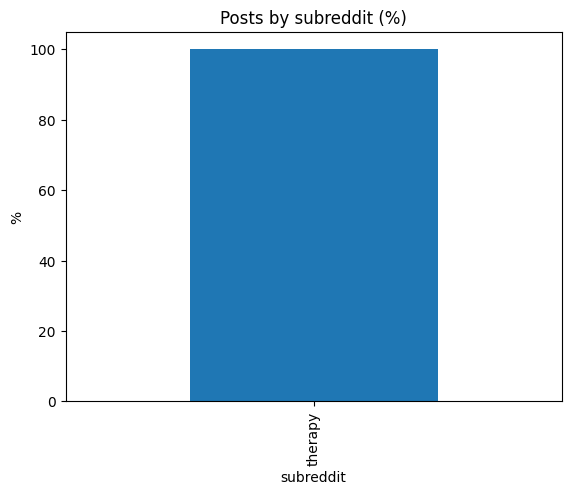

In [24]:
counts = clean_df["subreddit"].value_counts()
pct = (counts / counts.sum() * 100).round(1)
pct.plot(kind="bar", title="Posts by subreddit (%)", ylabel="%");
print(pct.to_string())

## Cost and Size Checks

In [25]:
import tiktoken

encoding = tiktoken.encoding_for_model("text-embedding-3-small")

def count_selftext_tokens(df, encoding):
    total_tokens = 0
    titles = df["title"].fillna("")
    selftexts = df["selftext"].fillna("")

    for i, (title, selftext) in enumerate(zip(titles, selftexts), 1):
        text = f"{title} | {selftext}"
        num_tokens = len(encoding.encode(str(text)))
        total_tokens += num_tokens
        if i % 20000 == 0:
            print(f"Token sum after {i} rows: {total_tokens:,}")

    print(f"Total tokens in df title|selftext: {total_tokens:,}")
    # openai text-embedding-3-small cost is $0.02 per million tokens
    cost = total_tokens / 1000000 * 0.02
    print(f"Cost: ${cost:.2f}")
    return

count_selftext_tokens(clean_df, encoding)


Token sum after 20000 rows: 7,384,494
Total tokens in df title|selftext: 9,218,011
Cost: $0.18


In [26]:
BYTES_PER_VALUE = 4   # float32


def estimate_vector_store_size(num_vectors, dim, bytes_per_value=BYTES_PER_VALUE):
    total_bytes = num_vectors * dim * bytes_per_value
    total_mb = total_bytes / (1024 ** 2)
    total_gb = total_bytes / (1024 ** 3)
    print(f"Estimated raw embedding storage for {num_vectors:,} vectors:")
    print(f"~{total_mb:,.2f} MB (~{total_gb:,.2f} GB) of float32 embeddings")
    return


num_vectors = len(clean_df)
estimate_vector_store_size(num_vectors, 1536)
estimate_vector_store_size(num_vectors, 512)
estimate_vector_store_size(num_vectors, 256)

Estimated raw embedding storage for 24,562 vectors:
~143.92 MB (~0.14 GB) of float32 embeddings
Estimated raw embedding storage for 24,562 vectors:
~47.97 MB (~0.05 GB) of float32 embeddings
Estimated raw embedding storage for 24,562 vectors:
~23.99 MB (~0.02 GB) of float32 embeddings


## Supabase setup

In [44]:
import vecs
import os
import dotenv
dotenv.load_dotenv()
DB_CONNECTION = os.environ.get("DB_CONNECTION")

vx = vecs.create_client(DB_CONNECTION)

In [45]:
docs = vx.get_or_create_collection(name="mental_health", dimension=512)

In [32]:
from openai import OpenAI

dotenv.load_dotenv()

client = OpenAI(
    api_key=os.environ.get("OPENAI_API_KEY"),
)


def create_embeddings(input):
    response = client.embeddings.create(
    model="text-embedding-3-small",
    input=input,
    encoding_format="float",
    dimensions=512
    )
    return response.data[0].embedding

## Upserting test

In [37]:
test_subsample_df = clean_df.head(5)
print(len(test_subsample_df))
print(test_subsample_df)

5
                 author                                           selftext  \
1      ohgreatimherenow  hey,\r  \nI'm a 17 year old guy that lives wit...   
2             HondaTalk  I'm 28. I've worked allied health jobs in the ...   
6  Aromatic-Fortune-793  TW MENTION OF RAPE\nTW EATING DISORDER \nTW AL...   
7          Music_Phasic  \nHow can I learn to forgive myself? Whenever ...   
8   SpecificCaptain5137  Im currently a Senior with a 2.75 GPA, I waite...   

   created_utc                                              title  \
1   1713536614                                        I need help   
2   1713537043  Biology degree, exhausted in career search. Ab...   
6   1713542887  Does my ex-best friend sound like a covert nar...   
7   1713542917                 How can I learn to forgive myself?   
8   1713543866   I feel like my life is ending because of collage   

                                           permalink subreddit subreddit_id  \
1           /r/therapy/comments/1c7

In [34]:
def create_embeddings_batch(texts):
    if not texts:
        return []
    response = client.embeddings.create(
        model="text-embedding-3-small",
        input=texts,
        encoding_format="float",
        dimensions=512
    )
    return [d.embedding for d in response.data]


def sanitize_metadata(row):
    """Vecs metadata: JSON-serializable primitives only (str, int, float, bool)."""
    return {
        "author": str(row["author"]) if pd.notna(row["author"]) else "",
        "created_utc": int(row["created_utc"]) if pd.notna(row["created_utc"]) else 0,
        "permalink": str(row["permalink"]) if pd.notna(row["permalink"]) else "",
        "subreddit": str(row["subreddit"]) if pd.notna(row["subreddit"]) else "",
        "subreddit_id": str(row["subreddit_id"]) if pd.notna(row["subreddit_id"]) else "",
        "link_flair_text": str(row["link_flair_text"]) if pd.notna(row["link_flair_text"]) else "",
        "retrieved_on": int(row["retrieved_on"]) if pd.notna(row["retrieved_on"]) else 0,
        "post_id": str(row["post_id"]),
        "title": str(row["title"]),
        "selftext": str(row["selftext"])
    }


BATCH_SIZE = 100
df_to_upsert = test_subsample_df

batch_df = df_to_upsert.head(BATCH_SIZE)
documents = (batch_df["title"] + " | " + batch_df["selftext"]).tolist()
embeddings = create_embeddings_batch(documents)

records = []
for i, (_, row) in enumerate(batch_df.iterrows()):
    post_id = str(row["post_id"])
    vec = embeddings[i]
    meta = sanitize_metadata(row)
    records.append((post_id, vec, meta))

docs.upsert(records=records)
print(f"Upserted {len(records)} records (ids = post_id).")

Upserted 5 records (ids = post_id).


In [46]:
docs.create_index(
    method=vecs.IndexMethod.hnsw,
    measure=vecs.IndexMeasure.cosine_distance
)

## Upsert to vecs with custom embeddings

Use `post_id` as the vector id. We create embeddings ourselves with OpenAI, then `docs.upsert(records=[(id, vector, metadata), ...])`.

In [39]:
# Full dataset: batch upsert with progress (resumable)
VECS_BATCH_SIZE = 100
vecs_progress_file = "data/vecs_upload_progress.txt"
df_to_upsert = clean_df

def load_vecs_progress(default_start: int = 0) -> int:
    if not os.path.exists(vecs_progress_file):
        return default_start
    with open(vecs_progress_file, "r") as f:
        return int(f.read().strip())


def save_vecs_progress(next_index: int) -> None:
    with open(vecs_progress_file, "w") as f:
        f.write(str(next_index))


start_idx = load_vecs_progress()
n_total = len(df_to_upsert)
print(f"Starting vecs upsert from index {start_idx} of {n_total}, batch size={VECS_BATCH_SIZE}.")

for batch_start in range(start_idx, n_total, VECS_BATCH_SIZE):
    batch_end = min(batch_start + VECS_BATCH_SIZE, n_total)
    batch_df = df_to_upsert.iloc[batch_start:batch_end]
    documents = (batch_df["title"] + " | " + batch_df["selftext"]).tolist()
    embeddings = create_embeddings_batch(documents)
    records = []
    for i, (_, row) in enumerate(batch_df.iterrows()):
        records.append((str(row["post_id"]), embeddings[i], sanitize_metadata(row)))
    try:
        docs.upsert(records=records)
        save_vecs_progress(batch_end)
        print(f"Upserted batch {batch_start}:{batch_end}.")
    except Exception as e:
        print(f"Error at batch {batch_start}:{batch_end}: {e}")
        break

Starting vecs upsert from index 18800 of 24562, batch size=100.
Upserted batch 18800:18900.
Upserted batch 18900:19000.
Upserted batch 19000:19100.
Upserted batch 19100:19200.
Upserted batch 19200:19300.
Upserted batch 19300:19400.
Upserted batch 19400:19500.
Upserted batch 19500:19600.
Upserted batch 19600:19700.
Upserted batch 19700:19800.
Upserted batch 19800:19900.
Upserted batch 19900:20000.
Upserted batch 20000:20100.
Upserted batch 20100:20200.
Upserted batch 20200:20300.
Upserted batch 20300:20400.
Upserted batch 20400:20500.
Upserted batch 20500:20600.
Upserted batch 20600:20700.
Upserted batch 20700:20800.
Upserted batch 20800:20900.
Upserted batch 20900:21000.
Upserted batch 21000:21100.
Upserted batch 21100:21200.
Upserted batch 21200:21300.
Upserted batch 21300:21400.
Upserted batch 21400:21500.
Upserted batch 21500:21600.
Upserted batch 21600:21700.
Upserted batch 21700:21800.
Upserted batch 21800:21900.
Upserted batch 21900:22000.
Upserted batch 22000:22100.
Upserted bat

In [47]:
post_query = """
This will be a long post so bear with me. I’m writing this all down for therapeutic purposes. But I would like some input on what was happening here and what to do at this point.

When I was in high school, I had a science teacher for two years (sophomore and junior year) and ended up becoming very close to him. Even though I wouldn’t admit it to anyone, not even myself, I was infatuated with him and experiencing limerence. He was very charming, and with me not having my father in the picture (my dad was an absent alcoholic) I latched on to him as a father figure. He was a good married man with three children. Sometimes he would make comments on how “petite” I was (I am a man) and touch my hair and shoulders. I deemed it as just paternal affection. I so desperately craved it, as I was going through a lot at home.

By senior year, him and I had a pretty profound rapport, and he even paid for me to go a school field trip in San Francisco with him and other students. When I graduated I asked for his number and we stayed in touch from there.

I went to college in NYC and there was a moment where he felt very involved and responsive even though I was away at school. At this point, I was very much in love with him (I could not admit it to myself yet). I would come back to Long Island regularly to visit him (I remember he affectionately touched my thigh while we got lunch together)

Anyway it all came to a head when he came out to the city to see me. He showed up at my dorm room and we eventually got some drinks together at a hookah bar. I remember he took his shoes off and put his feet right next to my lap. That’s about it. But from that point on he gradually withdrew. He became less responsive. While this was going on I started to drink heavily and eventually became an alcoholic.

When I was 20 (2012) I confessed to him that I was in love with him, and that I couldn’t talk to him for a while. His response was that I was a beautiful person and it was ok. A few months later we started talking again but by then my drinking was so bad that I threatened to kill myself over all of this and cursed him out. He promptly cut me out of his life. For years and years, any message I left from time to time was unanswered. Part of me understands why but another part of me felt it was so brutal and I was once again abandoned by someone I really loved.

Fast forward to 2021 - This same teacher is escorted out of school for disturbing allegations about his relationships with current/former female students. He was fired from the school.

This is now a long time ago, but to this day, I wonder where I fit into all of that. I am in a lovely relationship with a woman now, have a decent career, am nine years sober. I’ve moved on. But yet all of this still haunts me. I lost years of my life due to my attachment to him. I began to do sex work after he cut me out of his life and ended up getting sexually assaulted a few times.

After he was fired I reached out to him and he made an amends for cutting me off like that but that’s about it. I was selfishly trying to have him as an acquaintance again for “closure” but decided to cut him out of my life because the last thing I need is to regress emotionally. And what he did to those girls is reprehensible.

Was there abuse on his end? Or was I just crazy? Any feedback on this would be appreciated. Thank you.
"""

In [49]:
query_embeddings = create_embeddings(post_query)
documents = docs.query(
    data=query_embeddings,          
    limit=10,
    include_metadata=True,
)
for doc, metadata in documents:
    print(metadata["permalink"])

/r/therapy/comments/1pl72dx/as_i_overly_contributing_my_experience_to_the/
/r/therapy/comments/1ntij1f/psychiatrist_admitted_attraction_towards_me_is/
/r/therapy/comments/1e2c3vl/my_former_therapist_destroyed_my_life_and_enjoyed/
/r/mentalhealth/comments/1lifsgs/i_was_saed_by_a_man/
/r/mentalhealth/comments/1lh9fjf/how_to_mentally_deal_with_this/
/r/therapy/comments/1fvps2h/old_bully_28m_wants_me_27f_to_give_him_a_chance/
/r/mentalhealth/comments/1mmpzm1/my_ex_wants_to_talk/
/r/mentalhealth/comments/1ndopm9/a_former_friend_is_planning_to_take_his_life_and/
/r/mentalhealth/comments/1exei33/past_relationship_affecting_mental_health_causing/
/r/mentalhealth/comments/1cxh9w1/how_can_i_22m_heal_from_this_experience/
